In [1]:
import MDAnalysis as mda
import MDA_unwrap_PBC as unwrap
from scipy.fft import fft, ifft, dct, idct
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
TOPOL = "/Users/mheyden/Dropbox (ASU)/ASU-Research/POPC/run-NVE.tpr"
TRAJ = "/Users/mheyden/Dropbox (ASU)/ASU-Research/POPC/run-NVE_test.trr"
u = mda.Universe(TOPOL,TRAJ)

In [3]:
trees = unwrap.unwrap.buildTrees(u)

building intra-molecular bond trees ...
 -> detected 8016 molecules
 -> tree building time: 1.32s
 -> ready to unwrap


In [4]:
class transVDOS:
    def __init__(self,sel,nCorr):
        self.sel = sel
        self.nCorr = nCorr
        self.nRes = sel.residues.n_residues
        self.atMassLists = []
        for res in self.sel.residues:
            self.atMassLists.append(res.atoms.masses[:,np.newaxis])
        self.resMassList = sel.residues.masses
        self.COMposBuffer = np.zeros((nCorr, self.nRes, 3))
        self.COMvelBuffer = np.zeros((nCorr, self.nRes, 3))
        self.tau = np.zeros(nCorr, dtype = float)
        self.wavenumber = np.zeros(nCorr, dtype = float)
        self.corr = np.zeros((nCorr, sel.n_residues), dtype = float)
        self.vdos = np.zeros((nCorr, sel.n_residues), dtype = float)
        self.corrCnt = np.zeros(sel.n_residues, dtype = int)
        self.normalized = 0

    def COMinfo(self,tStep,time):
        idx = tStep % self.nCorr
        if tStep < self.nCorr:
            self.tau[tStep] = time
        r = 0
        for res in self.sel.residues:
            #self.COMposBuffer[idx,r] = res.atoms.center_of_mass() #too slow
            self.COMposBuffer[idx,r] = np.sum(self.atMassLists[r] * res.atoms.positions , axis = 0) / self.resMassList[r]
            self.COMvelBuffer[idx,r] = np.sum(self.atMassLists[r] * res.atoms.velocities, axis = 0) / self.resMassList[r]
            r += 1
        if tStep >= self.nCorr-1:
            self.calcCorr(tStep+1)

    def calcCorr(self,idx):
        for i in range(self.nCorr):
            j = idx % self.nCorr
            k = (j + i) % self.nCorr
            self.corr[i] += np.sum(self.COMvelBuffer[j] * self.COMvelBuffer[k], axis = 1)
        self.corrCnt += 1

    def normalize(self):
        if self.normalized == 0:
            for i in range(self.nRes):
                self.corr[:,i] *= self.resMassList[i] / self.corrCnt[i]
            self.normalized = 1
    
    def calcVDOS(self):
        period = (self.tau[1] - self.tau[0]) * (2 * self.nCorr - 1)
        wn0 = (1.0 / period) * 33.35641
        self.wavenumber = np.arange(0,self.nCorr) * wn0
        tmp = np.zeros(2 * self.nCorr - 1, dtype = float)
        for i in range(self.nRes):
            for j in range(self.nCorr):
                tmp[j] = self.corr[j][i]
            for j in range(1,self.nCorr):
                k = 2 * self.nCorr - j - 1
                tmp[k] = tmp[j]
            tmp = fft(tmp)
            for j in range(self.nCorr):
                self.vdos[j][i] = tmp[j].real / np.sqrt(2 * self.nCorr - 1)

In [5]:
sel = u.select_atoms("resname POPC")
trVDOS = transVDOS(sel,200)

In [6]:
tStep = 0
for ts in tqdm(u.trajectory):
    u.trajectory.ts._pos = unwrap.unwrap.unwrap(u,trees)
    trVDOS.COMinfo(tStep,ts.time)
    tStep += 1

100%|██████████| 626/626 [00:15<00:00, 39.91it/s]


In [7]:
trVDOS.normalize()
trVDOS.calcVDOS()

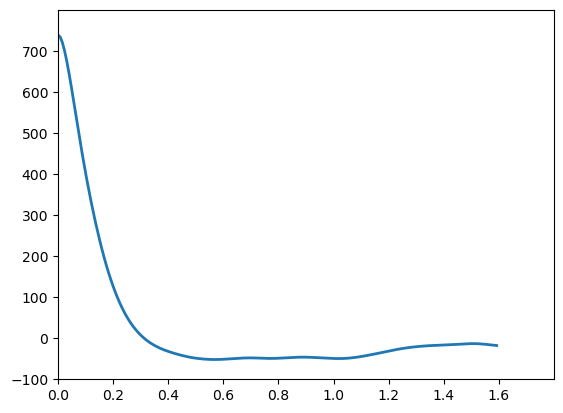

In [17]:
# plot
fig, ax = plt.subplots()
ax.plot(trVDOS.tau, np.sum(trVDOS.corr, axis = 1) / trVDOS.nRes, linewidth = 2.0)
ax.set(xlim=(0, 1.8), xticks=np.arange(0,1.8,0.2),
       ylim=(-100, 800), yticks=np.arange(-100,800,100))
plt.show()

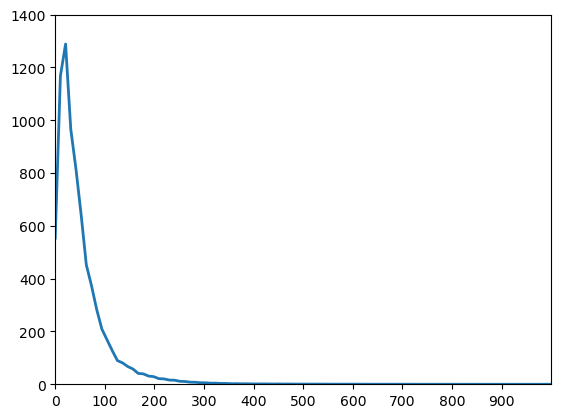

In [13]:
# plot
fig, ax = plt.subplots()
ax.plot(trVDOS.wavenumber, np.sum(trVDOS.vdos, axis = 1) / trVDOS.nRes, linewidth = 2.0)
ax.set(xlim=(0, 1000), xticks=np.arange(0,1000,100),
       ylim=(0, 1400.0), yticks=np.arange(0,1500,200))
plt.show()